In [2]:
from pathlib import Path
import pandas as pd

In [3]:
DATA_DIR=Path('final_data')
classes=["no_dr","mild","moderate","severe","proliferative_dr"]
count=0
for cls in classes:
    file=list((DATA_DIR/cls).glob("*"))
    count+=len(file)
    print(cls,len(file))
print("total count",count)

no_dr 1935
mild 393
moderate 1156
severe 278
proliferative_dr 360
total count 4122


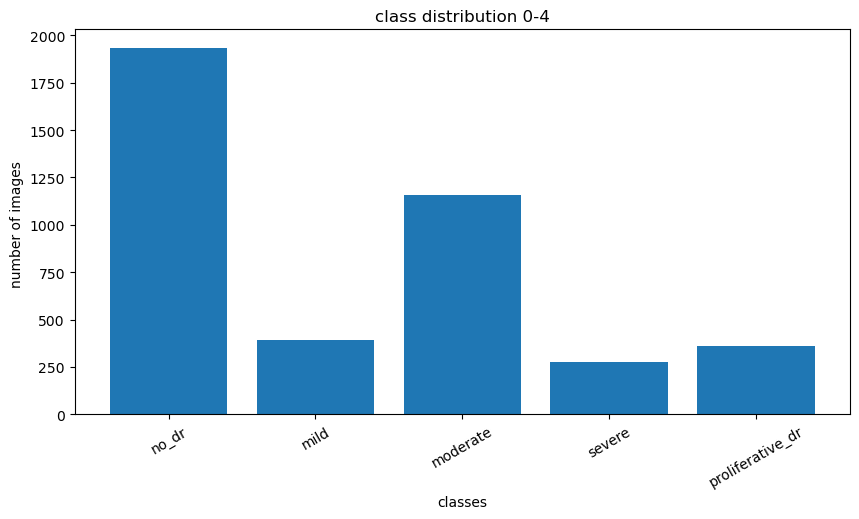

In [4]:
import matplotlib.pyplot as plt 
counts=[]


for cls in classes:
    count=len(list((DATA_DIR/cls).glob("*")))
    counts.append(count)

plt.figure(figsize=(10,5))
plt.bar(classes,counts)
plt.xticks(rotation=30)
plt.ylabel("number of images ")
plt.xlabel("classes")
plt.title("class distribution 0-4")
plt.show()

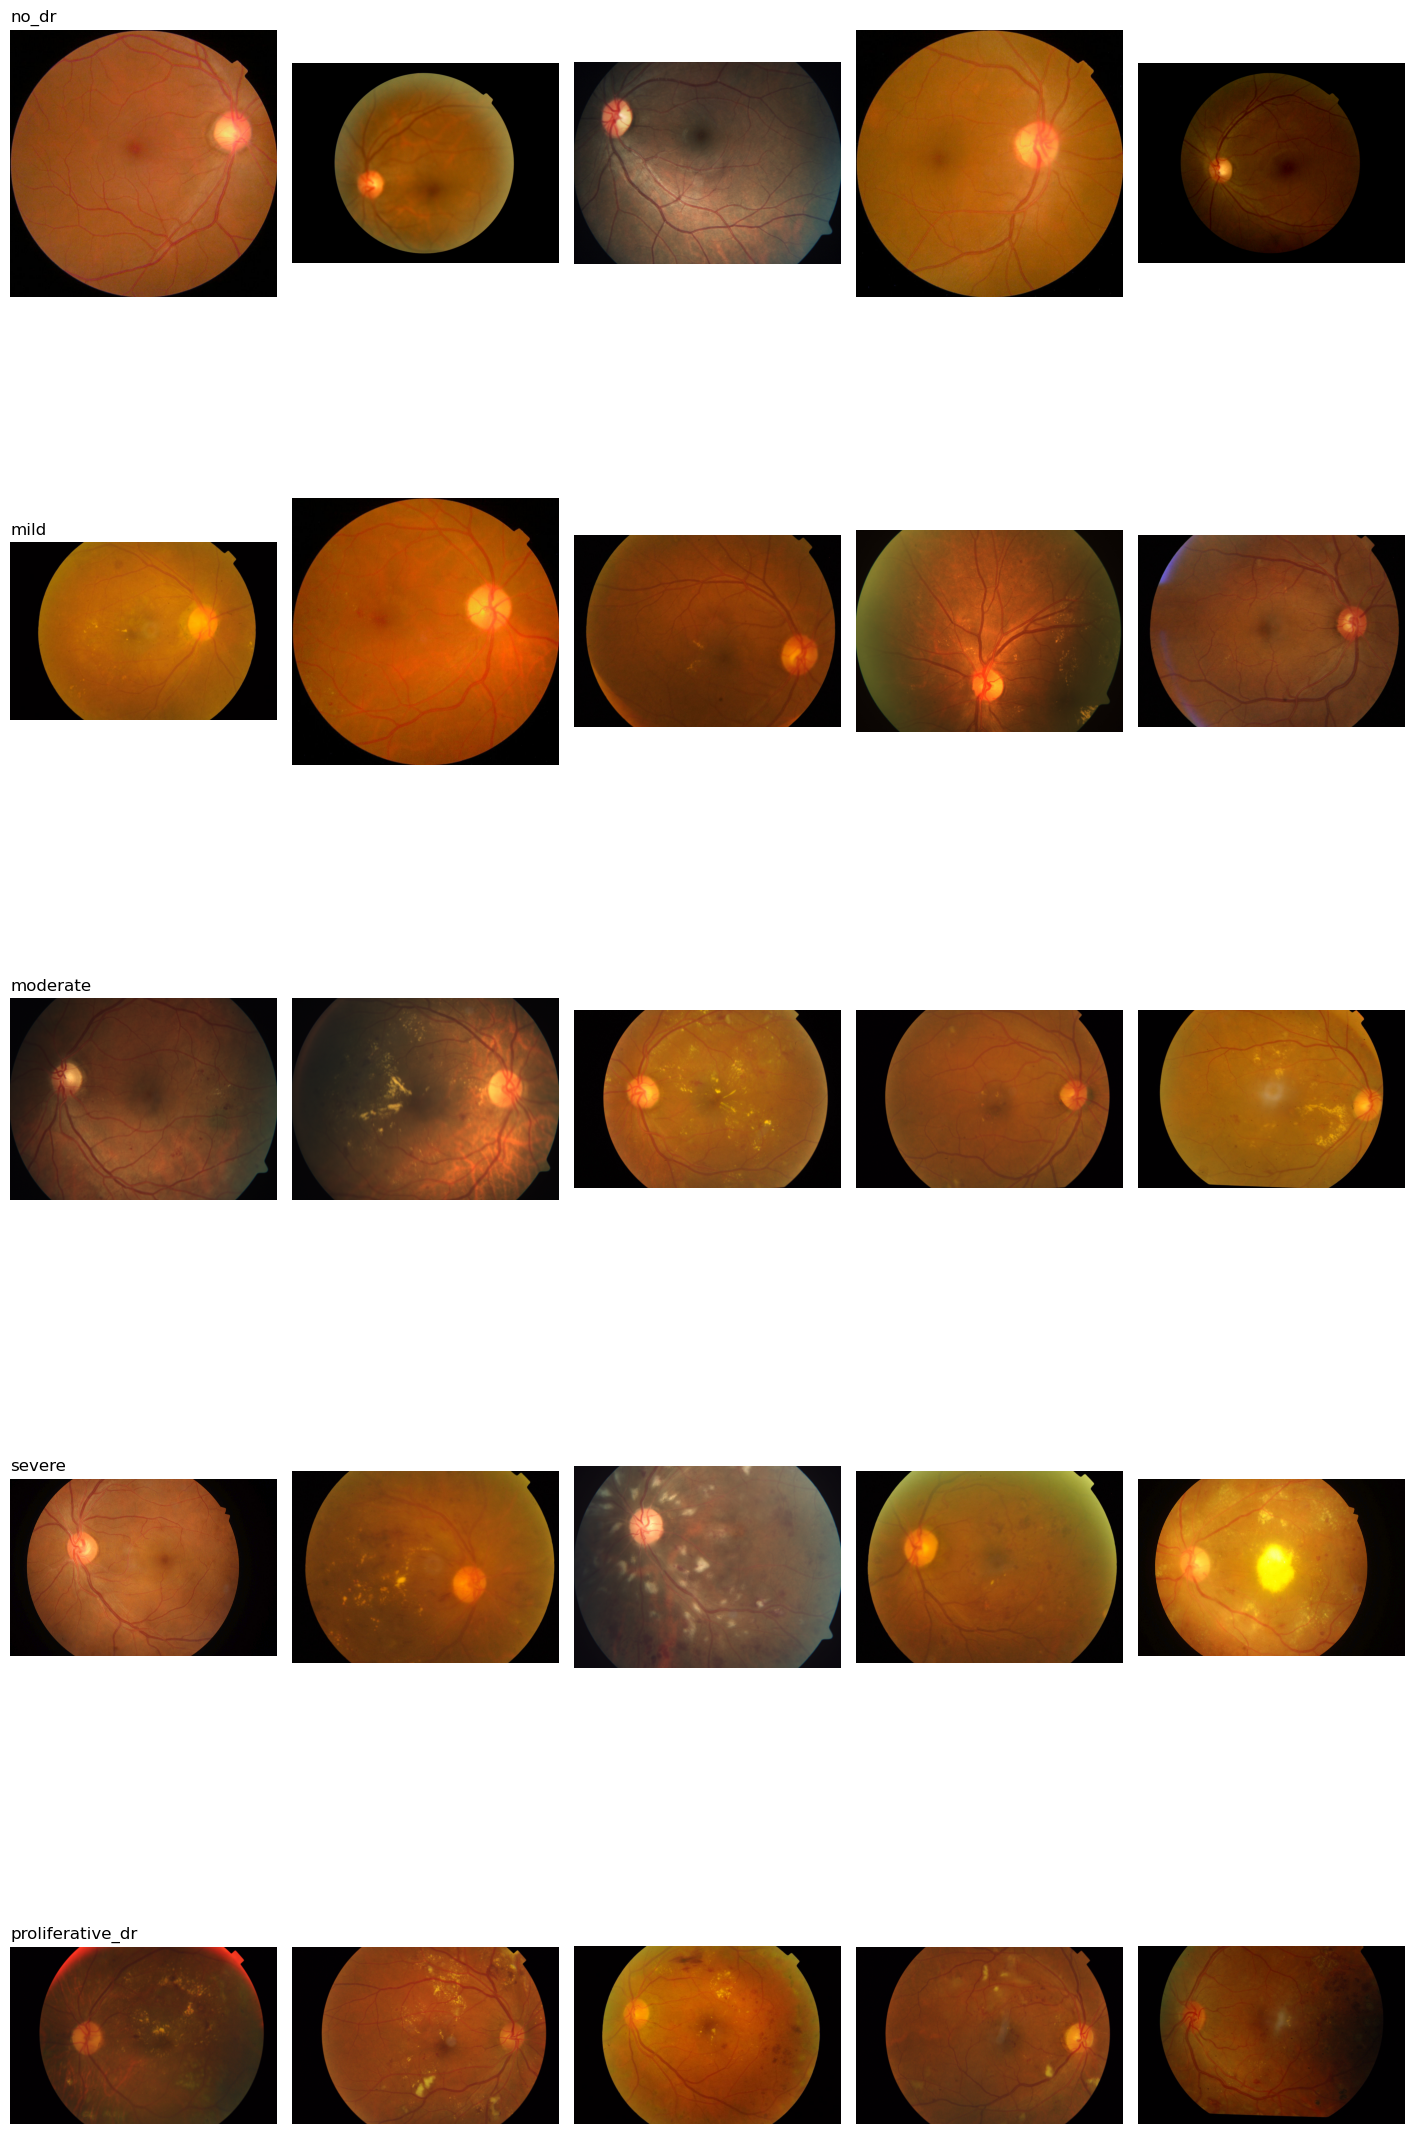

In [5]:
import random
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5 * len(classes)))

for i, cls in enumerate(classes):
    images = list((DATA_DIR / cls).glob("*"))
    selectedImages = random.sample(images, 5)

    for col, imagePath in enumerate(selectedImages):
        image = Image.open(imagePath)

        plt.subplot(len(classes), 5, i * 5 + col + 1)
        plt.imshow(image)
        plt.axis("off")

        if col == 0:
            plt.title(cls, fontsize=12, loc="left")

plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()

In [6]:
from collections import Counter

sizes = Counter()

for cls in classes:

    for img_path in (DATA_DIR / cls).glob("*"):

        try:
            img = Image.open(img_path)
            sizes[img.size] += 1
        except:
            pass

print(sizes.most_common(20))

[((1050, 1050), 974), ((2416, 1736), 638), ((2588, 1958), 533), ((4288, 2848), 512), ((3216, 2136), 410), ((2048, 1536), 351), ((819, 614), 287), ((3388, 2588), 141), ((1504, 1000), 92), ((1844, 1226), 61), ((640, 480), 42), ((2896, 1944), 34), ((2144, 1424), 28), ((1476, 1117), 14), ((474, 358), 2), ((1467, 1110), 2), ((2146, 1764), 1)]


In [7]:
modes=Counter()
for cls in classes:

    for imgPath in (DATA_DIR/cls).glob("*"):
        try:
            img=Image.open(imgPath)
            modes[img.mode]+=1

        except:
            pass

print(modes)

Counter({'RGB': 4122})


In [8]:
import numpy as np
means=[]
std=[]

for cls in classes:
    for imgPath in (DATA_DIR/cls).glob("*"):
        img=np.array(Image.open(imgPath).convert("RGB"))

        means.append(img.mean())
        std.append(img.std())

print('AVERAWGE picle intesntist',np.mean(means))
print('AVERAWGE picle std deviation',np.mean(std))

AVERAWGE picle intesntist 60.34340117942818
AVERAWGE picle std deviation 56.286358042219746


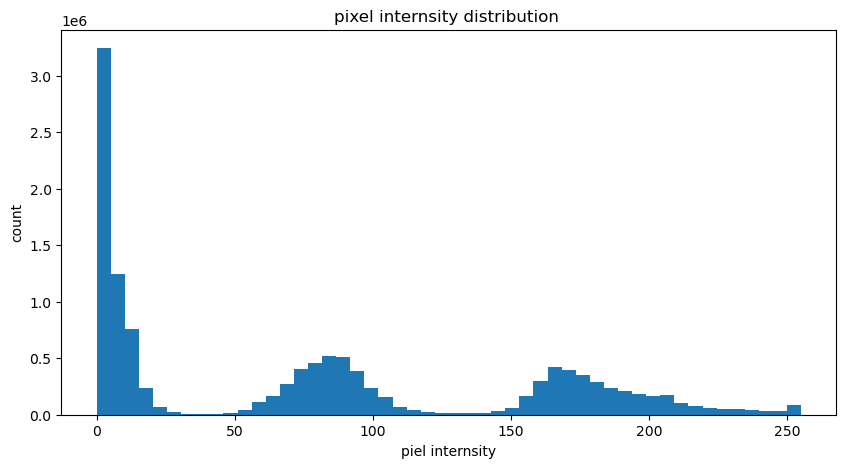

In [9]:
plt.figure(figsize=(10,5))
img=np.array(Image.open(random.choice(list((DATA_DIR/"moderate").glob("*")))).convert("RGB"))

plt.hist(img.ravel(),bins=50)
plt.xlabel("piel internsity")
plt.ylabel("count")
plt.title("pixel internsity distribution ")
plt.show()

In [10]:
import cv2
import numpy as np

def blur_score(image_path):

    img = cv2.imread(str(image_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return cv2.Laplacian(gray, cv2.CV_64F).var()

In [11]:
scores = []

for cls in classes:
    for img_path in (DATA_DIR / cls).glob("*"):
        try:
            score = blur_score(img_path)
            scores.append({
                "class": cls,
                "image": img_path.name,
                "blur_score": score
            })
        except Exception as e:
            print("Error:", img_path, e)

blur_df = pd.DataFrame(scores)

print("Mean blur score:", blur_df['blur_score'].mean())


Mean blur score: 23.747754809054374


In [12]:
blur_df.head()

,class,image,blur_score
0,no_dr,aptos_002c21358ce6.png,42.167755
1,no_dr,aptos_005b95c28852.png,27.614819
2,no_dr,aptos_0097f532ac9f.png,12.599714
3,no_dr,aptos_00cc2b75cddd.png,38.565752
4,no_dr,aptos_00f6c1be5a33.png,45.413593


In [13]:
records = []

for cls in classes:
    class_dir = DATA_DIR / cls
    
    for img_path in class_dir.glob("*"):
        try:
            img = cv2.imread(str(img_path))
            
            if img is None:
                continue
            
            h, w = img.shape[:2]
            
            if len(img.shape) == 3:
                channels = img.shape[2]
            else:
                channels = 1
            
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
            brightness = gray.mean()
            contrast = gray.std()
            
            fg_mask = gray > 10          # same threshold as black_ratio, inverted
            black_ratio = np.mean(~fg_mask)
            
            # brightness/contrast computed on retina pixels only (background excluded)
            if fg_mask.sum() > 0:
                masked_brightness = gray[fg_mask].mean()
                masked_contrast = gray[fg_mask].std()
            else:
                masked_brightness = np.nan
                masked_contrast = np.nan
            
            records.append({
                "class": cls,
                "image": img_path.name,
                "width": w,
                "height": h,
                "channels": channels,
                "aspect_ratio": w / h,
                "resolution": f"{w}x{h}",
                "brightness": brightness,
                "contrast": contrast,
                "black_ratio": black_ratio,
                "masked_brightness": masked_brightness,
                "masked_contrast": masked_contrast
            })
            
        except Exception as e:
            print("Error:", img_path, e)

image_df = pd.DataFrame(records)

print("Total valid images:", len(image_df))

image_df.head()


Total valid images: 4122


,class,image,width,height,channels,aspect_ratio,resolution,brightness,contrast,black_ratio,masked_brightness,masked_contrast
0,no_dr,aptos_002c21358ce6.png,1050,1050,3,1.000000,1050x1050,85.499236,46.504284,0.209702,107.868567,18.703931
1,no_dr,aptos_005b95c28852.png,2048,1536,3,1.333333,2048x1536,22.645921,26.404921,0.526060,47.749717,16.523038
2,no_dr,aptos_0097f532ac9f.png,2588,1958,3,1.321757,2588x1958,49.541231,16.814747,0.015319,50.158301,16.194965
3,no_dr,aptos_00cc2b75cddd.png,1050,1050,3,1.000000,1050x1050,77.169665,41.750427,0.209013,97.147796,17.132996
4,no_dr,aptos_00f6c1be5a33.png,1050,1050,3,1.000000,1050x1050,76.716656,41.445276,0.209140,96.749033,15.895395


In [14]:
image_df = image_df.merge(
    blur_df[["class", "image", "blur_score"]],
    on=["class", "image"],
    how="left"
)

image_df[["class", "image", "blur_score"]].head()


,class,image,blur_score
0,no_dr,aptos_002c21358ce6.png,42.167755
1,no_dr,aptos_005b95c28852.png,27.614819
2,no_dr,aptos_0097f532ac9f.png,12.599714
3,no_dr,aptos_00cc2b75cddd.png,38.565752
4,no_dr,aptos_00f6c1be5a33.png,45.413593


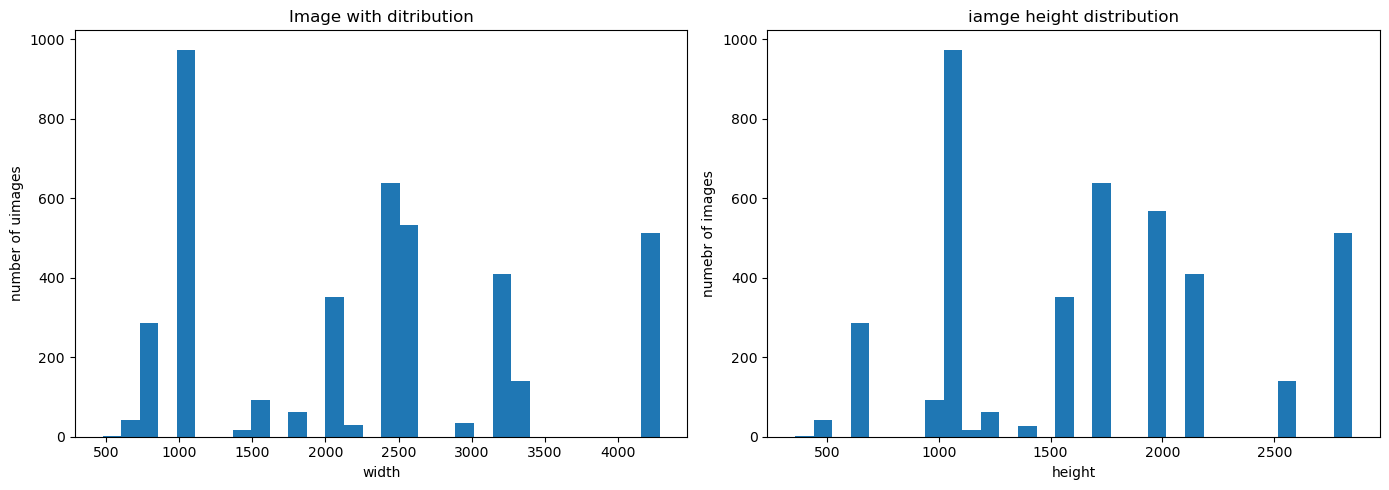

In [15]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(image_df['width'],bins=30)
axes[0].set_title('Image with ditribution')
axes[0].set_xlabel('width')
axes[0].set_ylabel('number of uimages')

axes[1].hist(image_df['height'],bins=30)
axes[1].set_title("iamge height distribution")
axes[1].set_ylabel("numebr of images")
axes[1].set_xlabel("height")

plt.tight_layout()
plt.show()

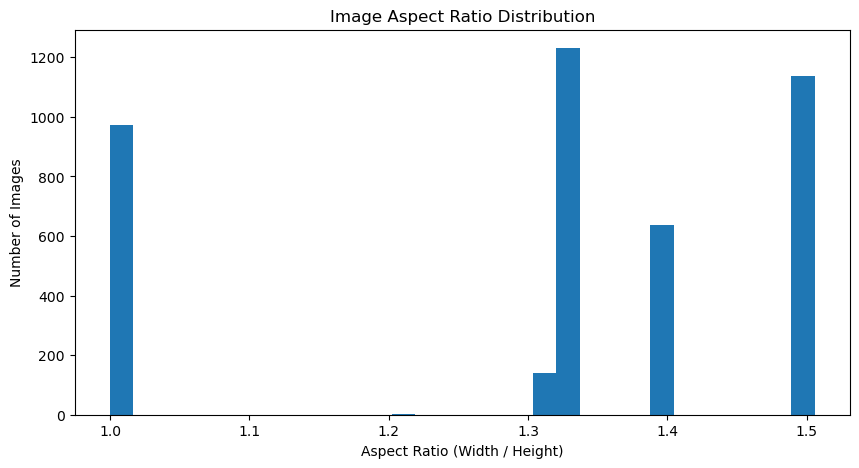

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(image_df["aspect_ratio"], bins=30)

plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Number of Images")
plt.title("Image Aspect Ratio Distribution")

plt.show()

<Figure size 1000x500 with 0 Axes>

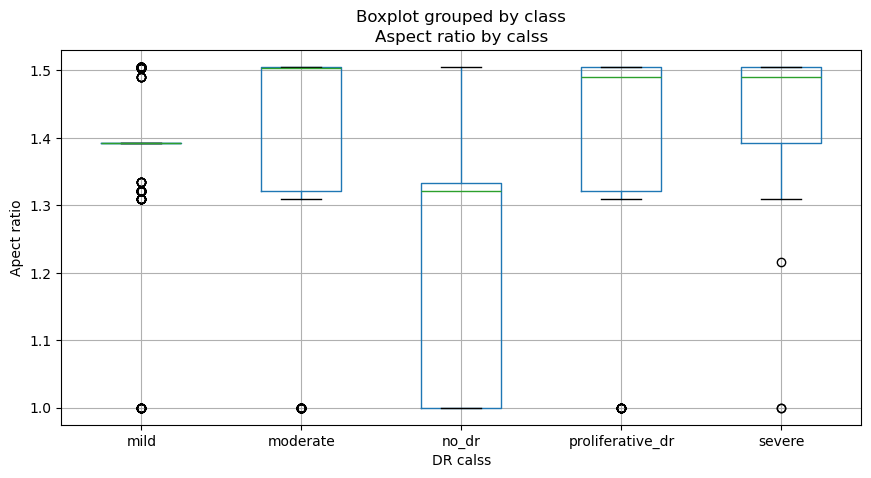

In [17]:
plt.figure(figsize=(10,5))

image_df.boxplot(column='aspect_ratio',by="class",figsize=(10,5))
plt.title("Aspect ratio by calss")
plt.xlabel("DR calss")
plt.ylabel("Apect ratio")
plt.show()

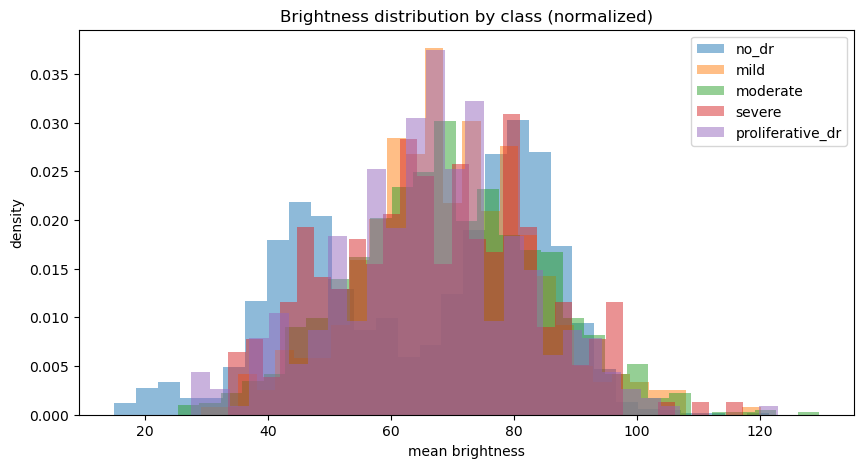

In [18]:
plt.figure(figsize=(10,5))

for cls in classes:
    data = image_df[image_df['class']==cls]['brightness']
    plt.hist(data, bins=30, alpha=0.5, label=cls, density=True)

plt.xlabel("mean brightness")
plt.ylabel("density")
plt.title("Brightness distribution by class (normalized)")
plt.legend()
plt.show()


<Axes: title={'center': 'brightness'}, xlabel='class'>

<Figure size 1000x500 with 0 Axes>

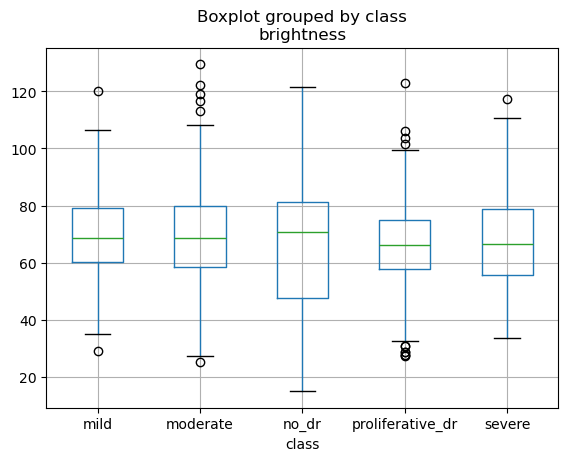

In [19]:
plt.figure(figsize=(10,5))

image_df.boxplot(column='brightness',by='class')

<Figure size 1000x500 with 0 Axes>

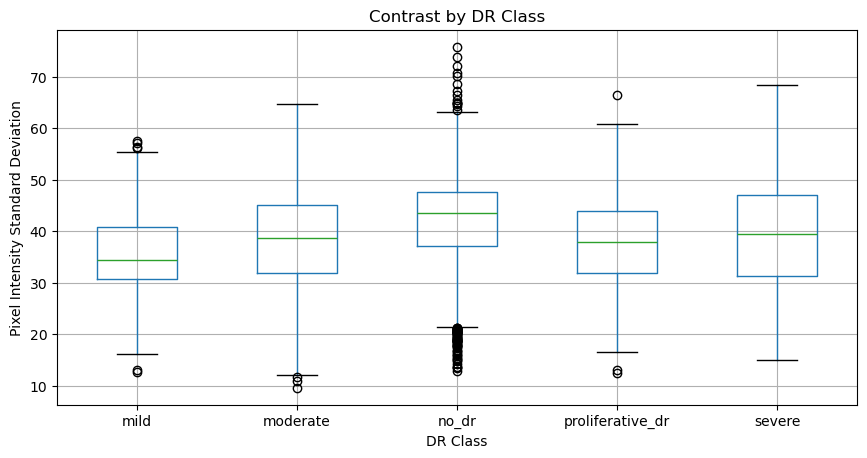

In [20]:
plt.figure(figsize=(10, 5))

image_df.boxplot(
    column="contrast",
    by="class",
    figsize=(10, 5)
)

plt.title("Contrast by DR Class")
plt.suptitle("")
plt.xlabel("DR Class")
plt.ylabel("Pixel Intensity Standard Deviation")

plt.show()

<Axes: title={'center': 'black_ratio'}, xlabel='class'>

<Figure size 1000x500 with 0 Axes>

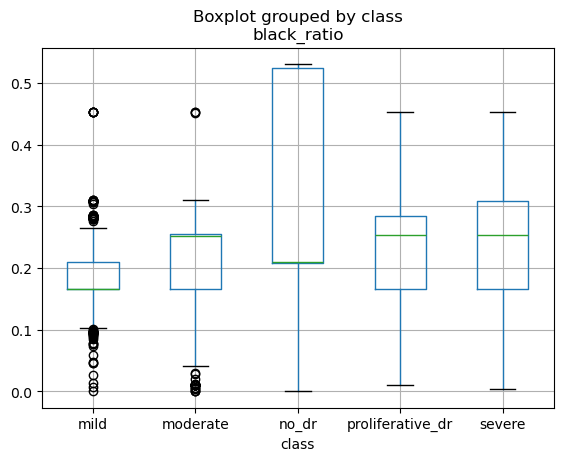

In [21]:
plt.figure(figsize=(10,5))
image_df.boxplot(column="black_ratio",by='class')

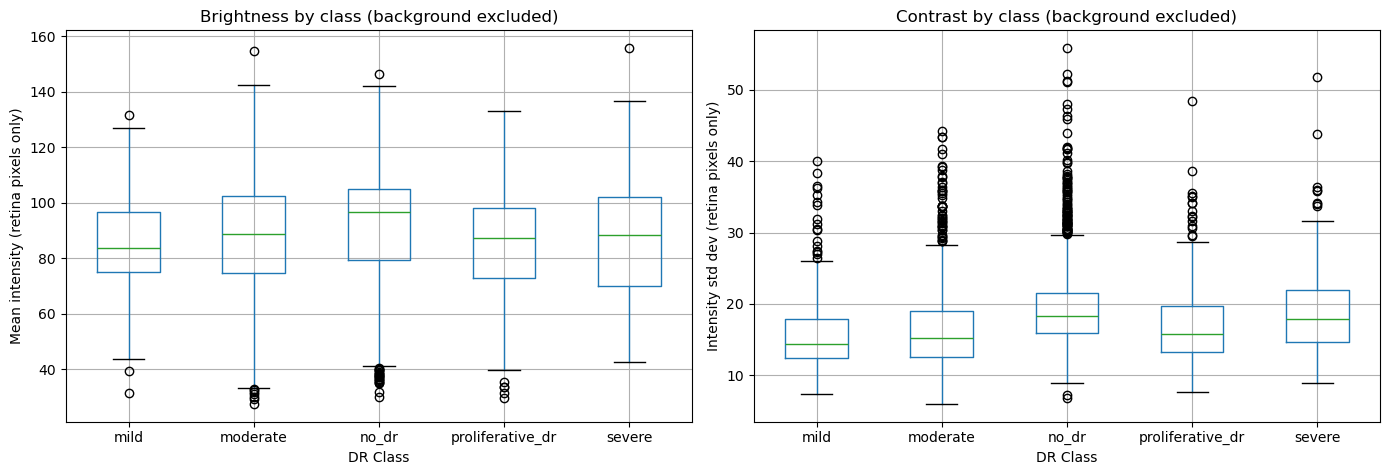

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

image_df.boxplot(column="masked_brightness", by="class", ax=axes[0])
axes[0].set_title("Brightness by class (background excluded)")
axes[0].set_xlabel("DR Class")
axes[0].set_ylabel("Mean intensity (retina pixels only)")

image_df.boxplot(column="masked_contrast", by="class", ax=axes[1])
axes[1].set_title("Contrast by class (background excluded)")
axes[1].set_xlabel("DR Class")
axes[1].set_ylabel("Intensity std dev (retina pixels only)")

plt.suptitle("")
plt.tight_layout()
plt.show()


<Figure size 1000x500 with 0 Axes>

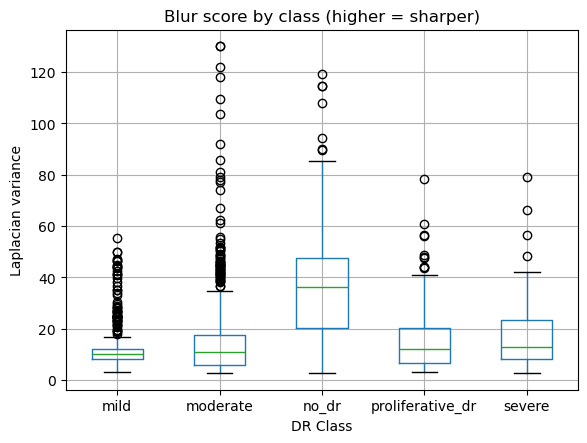

In [23]:
plt.figure(figsize=(10,5))
image_df.boxplot(column="blur_score", by="class")
plt.title("Blur score by class (higher = sharper)")
plt.suptitle("")
plt.xlabel("DR Class")
plt.ylabel("Laplacian variance")
plt.show()


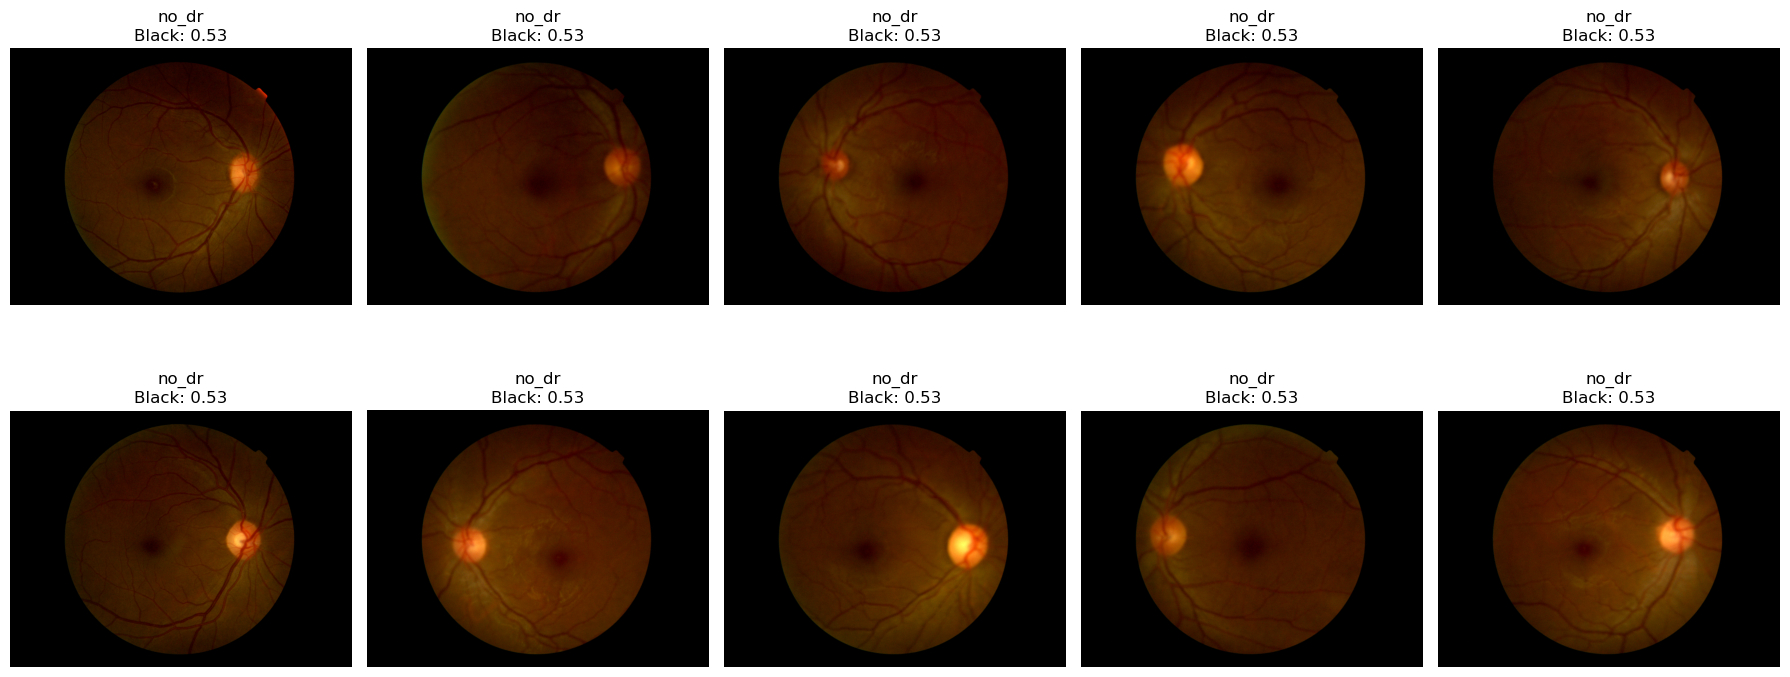

In [24]:
top_black = image_df.sort_values(
    "black_ratio",
    ascending=False
).head(10)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for ax, (_, row) in zip(axes.flat, top_black.iterrows()):
    
    img_path = DATA_DIR / row["class"] / row["image"]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(img)
    ax.set_title(
        f'{row["class"]}\nBlack: {row["black_ratio"]:.2f}'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

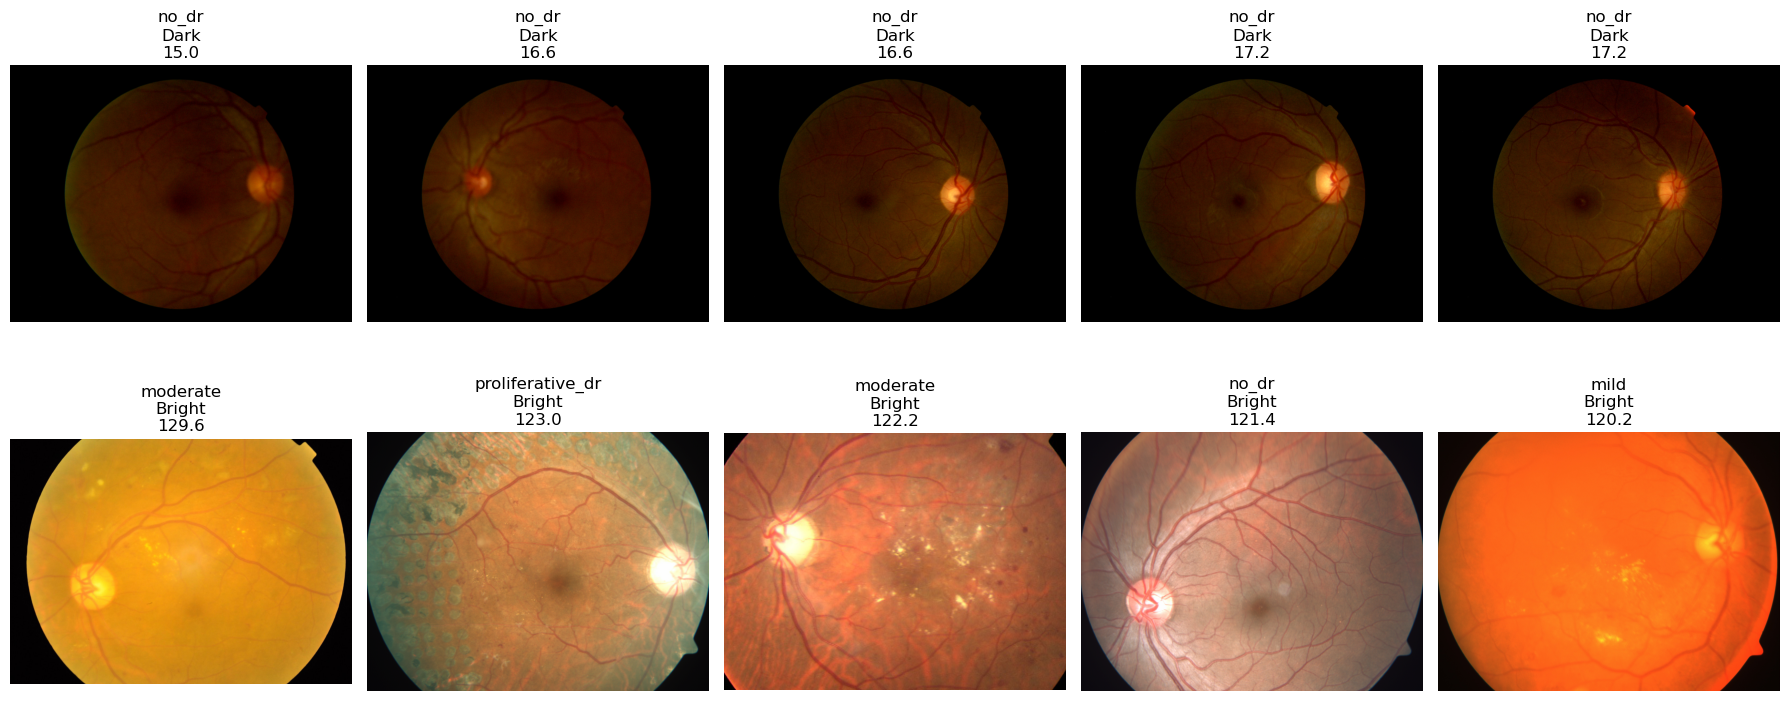

In [25]:
darkest = image_df.nsmallest(5, "brightness")
brightest = image_df.nlargest(5, "brightness")

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for ax, (_, row) in zip(axes[0], darkest.iterrows()):
    
    img_path = DATA_DIR / row["class"] / row["image"]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(img)
    ax.set_title(f'{row["class"]}\nDark\n{row["brightness"]:.1f}')
    ax.axis("off")

for ax, (_, row) in zip(axes[1], brightest.iterrows()):
    
    img_path = DATA_DIR / row["class"] / row["image"]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(img)
    ax.set_title(f'{row["class"]}\nBright\n{row["brightness"]:.1f}')
    ax.axis("off")

plt.tight_layout()
plt.show()

In [26]:
from IPython.display import display

res_crosstab = pd.crosstab(image_df["class"], image_df["resolution"])
res_crosstab_pct = pd.crosstab(image_df["class"], image_df["resolution"], normalize="index") * 100

print("Image count per class per resolution:")
display(res_crosstab)

print("\n% of each class coming from each resolution (check for source-dataset skew):")
display(res_crosstab_pct.round(1))


Image count per class per resolution:


resolution,1050x1050,1467x1110,1476x1117,1504x1000,1844x1226,2048x1536,2144x1424,2146x1764,2416x1736,2588x1958,2896x1944,3216x2136,3388x2588,4288x2848,474x358,640x480,819x614
class,,,,,,,,,,,,,,,,,
mild,19,0,0,2,13,0,1,0,234,44,6,13,13,41,0,0,7
moderate,39,2,0,63,28,0,22,0,233,165,3,307,91,168,1,33,1
no_dr,901,0,10,0,0,351,0,0,31,231,0,2,0,130,0,0,279
proliferative_dr,13,0,2,18,19,0,2,0,80,46,4,56,31,84,1,4,0
severe,2,0,2,9,1,0,3,1,60,47,21,32,6,89,0,5,0



% of each class coming from each resolution (check for source-dataset skew):


resolution,1050x1050,1467x1110,1476x1117,1504x1000,1844x1226,2048x1536,2144x1424,2146x1764,2416x1736,2588x1958,2896x1944,3216x2136,3388x2588,4288x2848,474x358,640x480,819x614
class,,,,,,,,,,,,,,,,,
mild,4.8,0.0,0.0,0.5,3.3,0.0,0.3,0.0,59.5,11.2,1.5,3.3,3.3,10.4,0.0,0.0,1.8
moderate,3.4,0.2,0.0,5.4,2.4,0.0,1.9,0.0,20.2,14.3,0.3,26.6,7.9,14.5,0.1,2.9,0.1
no_dr,46.6,0.0,0.5,0.0,0.0,18.1,0.0,0.0,1.6,11.9,0.0,0.1,0.0,6.7,0.0,0.0,14.4
proliferative_dr,3.6,0.0,0.6,5.0,5.3,0.0,0.6,0.0,22.2,12.8,1.1,15.6,8.6,23.3,0.3,1.1,0.0
severe,0.7,0.0,0.7,3.2,0.4,0.0,1.1,0.4,21.6,16.9,7.6,11.5,2.2,32.0,0.0,1.8,0.0


In [27]:
curr_cols = list(image_df.columns)

curr_cols = [col for col in curr_cols if col not in ['class', 'image', 'channels']]

corr=image_df[curr_cols].corr()

plt.figure(figsize=(15,6))
plt.imshow(corr,interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(curr_cols)),curr_cols,rotation=45,ha='right')
plt.yticks(range(len(curr_cols)),curr_cols )
plt.title("correlation analysi ")
plt.tight_layout()
plt.show()

ValueError: could not convert string to float: '1050x1050'

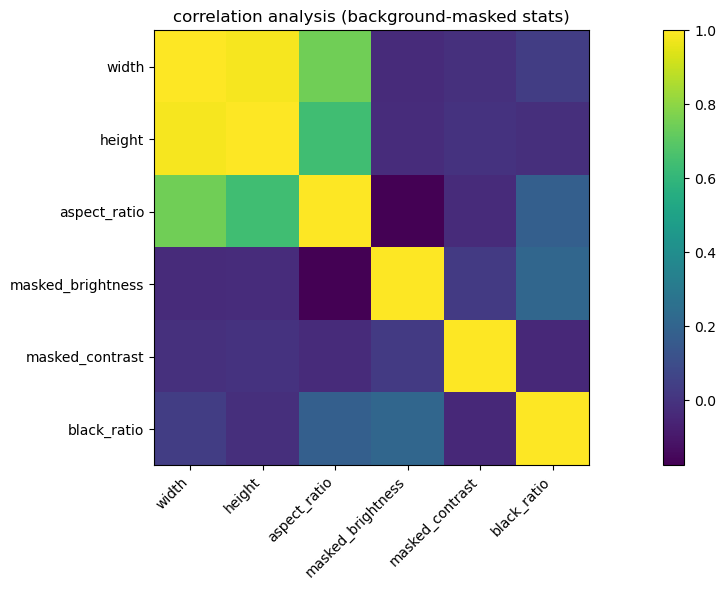

In [ ]:
masked_cols = ["width", "height", "aspect_ratio", "masked_brightness", "masked_contrast", "black_ratio"]

masked_corr = image_df[masked_cols].corr()

plt.figure(figsize=(15,6))
plt.imshow(masked_corr, interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(masked_cols)), masked_cols, rotation=45, ha="right")
plt.yticks(range(len(masked_cols)), masked_cols)
plt.title("correlation analysis (background-masked stats)")
plt.tight_layout()
plt.show()


In [ ]:
import hashlib

hash_records = []

for cls in classes:
    for img_path in (DATA_DIR / cls).glob("*"):
        
        try:
            with open(img_path, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
            
            hash_records.append({
                "class": cls,
                "image": img_path.name,
                "hash": file_hash
            })
            
        except:
            pass

hash_df = pd.DataFrame(hash_records)

duplicates = hash_df[
    hash_df.duplicated("hash", keep=False)
].sort_values("hash")

print("Number of duplicated files:", len(duplicates))

print("no_dr duplicates:", len(duplicates[duplicates['class']=='no_dr']))


Number of duplicated files: 271
no_dr duplicates: 17


In [ ]:
print(duplicates.groupby('class').size())

class
mild                 56
moderate            137
no_dr                17
proliferative_dr     39
severe               22
dtype: int64


In [ ]:
dup_groups = (
    hash_df[hash_df.duplicated("hash", keep=False)]
    .groupby("hash")
    .agg(
        files=("image", "count"),
        classes=("class", lambda x: list(x.unique()))
    )
    .reset_index()
)

dup_groups["class_count"] = dup_groups["classes"].apply(len)

dup_groups.sort_values(
    ["class_count", "files"],
    ascending=False
).head(30)

,hash,files,classes,class_count
58,76773eca8d3a286e9baf4c146745d912,3,"[moderate, severe]",2
123,ece61abc754cc776d087ab5ba13e3837,3,"[mild, moderate]",2
5,197303f49434137ed6ab3c9906d76a13,2,"[severe, proliferative_dr]",2
9,22f5076c4ee1788e4e80c44b3d459e93,2,"[moderate, severe]",2
14,292a349e96cc5560aeb965019b116180,2,"[moderate, severe]",2
16,2a613e17fe7eebeca8a21ac5f46e8ec2,2,"[moderate, proliferative_dr]",2
18,2f72ef33ec56843d7425e8c599d73ab1,2,"[no_dr, mild]",2
20,374fb66d60f97af7ff2c679f81063fbb,2,"[moderate, proliferative_dr]",2
23,3be1e5644df038399c1d31319e733af1,2,"[moderate, proliferative_dr]",2
43,6b82af09990c57a676fc03856e4b3400,2,"[mild, moderate]",2


In [ ]:
conflicting = dup_groups[dup_groups["class_count"] > 1]

print("Duplicate groups:", len(dup_groups))
print("Conflicting-label groups:", len(conflicting))

Duplicate groups: 133
Conflicting-label groups: 32


In [ ]:
conflicting_hashes = conflicting["hash"].tolist()

conflicting_details = hash_df[hash_df["hash"].isin(conflicting_hashes)].sort_values(["hash", "class"])

conflicting_details


In [ ]:
sample_hashes = conflicting_hashes[:4]   # inspect the first few conflicting groups

fig, axes = plt.subplots(len(sample_hashes), 3, figsize=(12, 4 * len(sample_hashes)))

for row, h in enumerate(sample_hashes):
    group = hash_df[hash_df["hash"] == h]
    
    for col, (_, r) in enumerate(group.iterrows()):
        if col >= 3:
            break
        img_path = DATA_DIR / r["class"] / r["image"]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        ax = axes[row, col] if len(sample_hashes) > 1 else axes[col]
        ax.imshow(img)
        ax.set_title(f'{r["class"]}\n{r["image"]}', fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Attach the file hash to every row so duplicates (including cross-class ones)
# can be grouped together for a leakage-safe train/val/test split.
image_df = image_df.merge(hash_df[["class", "image", "hash"]], on=["class", "image"], how="left")

# For hash groups where the label disagrees across classes, decide a resolution
# strategy before training. Simplest defensible default: keep the first
# occurrence, drop the rest, and manually re-check the dropped conflicting
# ones (see conflicting_details above) rather than trusting either label blindly.
image_df_dedup = image_df.drop_duplicates(subset="hash", keep="first").reset_index(drop=True)

print("Before dedup:", len(image_df))
print("After dedup:", len(image_df_dedup))
print("Rows removed:", len(image_df) - len(image_df_dedup))

# image_df_dedup["hash"] can now be passed as `groups` to
# sklearn.model_selection.GroupShuffleSplit / GroupKFold so no duplicate
# image (even a relabeled one) ends up split across train/val/test.


In [ ]:
num_duplicate_groups = hash_df[
    hash_df.duplicated("hash", keep=False)
]["hash"].nunique()

print(num_duplicate_groups)

133
